# LightGBM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import shap

/Users/takahashishinji/portfolio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# データの読み込み
df = pd.read_csv('../data/adult.csv')

# 2値分類の目的変数の作成
df['income_binary'] = (df['income'] == '>50K').astype(int)

# 不要列削除
df = df.drop(columns=['fnlwgt', 'education', 'income'])

# 列名のドットをアンダーバーに置換
df.columns = df.columns.str.replace('.', '_', regex=False)

# 欠損値「?」をUnknownに置換
cols = ['workclass', 'occupation', 'native_country']
df[cols] = df[cols].replace('?', 'Unknown')

In [3]:
# 説明変数と目的変数の分離
X = df.drop('income_binary', axis=1)
y = df['income_binary']

In [4]:
# train_test分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [5]:
# 全foldでカテゴリを固定（クロスバリデーションのエラー対策）
cat_cols = [
    'workclass','occupation','marital_status',
    'relationship','race','sex','native_country' 
]

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    # X_trainのカテゴリ定義を用いてX_testをカテゴリ型に変換
    X_test[col] = pd.Categorical(
        X_test[col], 
        categories=X_train[col].cat.categories
    )

## バリデーション設計（クロスバリデーション・確認用）

In [6]:
n_splits = 5
cv = list(StratifiedKFold(
    n_splits=n_splits, 
    shuffle=True, 
    random_state=123
).split(X_train, y_train))

for nfold, (train_index, valid_index) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    X_train_fold = X_train.iloc[train_index]
    y_train_fold = y_train.iloc[train_index]
    
    X_valid_fold = X_train.iloc[valid_index]
    y_valid_fold = y_train.iloc[valid_index]
    
    print(X_train_fold.shape, y_train_fold.shape)
    print(X_valid_fold.shape, y_valid_fold.shape)
    print(f'y_train : {y_train.mean()}, y_train_fold : {y_train_fold.mean()}, y_valid_fold : {y_valid_fold.mean()}')

-------------------- 0 --------------------
(20838, 12) (20838,)
(5210, 12) (5210,)
y_train : 0.23948095823095822, y_train_fold : 0.23946635953546405, y_valid_fold : 0.23953934740882918
-------------------- 1 --------------------
(20838, 12) (20838,)
(5210, 12) (5210,)
y_train : 0.23948095823095822, y_train_fold : 0.23946635953546405, y_valid_fold : 0.23953934740882918
-------------------- 2 --------------------
(20838, 12) (20838,)
(5210, 12) (5210,)
y_train : 0.23948095823095822, y_train_fold : 0.23946635953546405, y_valid_fold : 0.23953934740882918
-------------------- 3 --------------------
(20839, 12) (20839,)
(5209, 12) (5209,)
y_train : 0.23948095823095822, y_train_fold : 0.23950285522337925, y_valid_fold : 0.23939335765022077
-------------------- 4 --------------------
(20839, 12) (20839,)
(5209, 12) (5209,)
y_train : 0.23948095823095822, y_train_fold : 0.23950285522337925, y_valid_fold : 0.23939335765022077


## モデル学習

In [7]:
n_splits = 5
cv = list(StratifiedKFold(
    n_splits=n_splits, 
    shuffle=True, 
    random_state=123
).split(X_train, y_train))
scores = []

for nfold, (train_index, valid_index) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    X_train_fold = X_train.iloc[train_index]
    y_train_fold = y_train.iloc[train_index]
    
    X_valid_fold = X_train.iloc[valid_index]
    y_valid_fold = y_train.iloc[valid_index]

    model_lgb = lgb.LGBMClassifier(
        boosting_type='gbdt', 
        objective='binary', 
        learning_rate=0.1, 
        num_leaves=16, 
        n_estimators=100000,
        random_state=123, 
        importance_type='gain'
    )

    model_lgb.fit(
        X_train_fold,
        y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(50), 
            lgb.log_evaluation(100)
        ]
    )

    y_pred = model_lgb.predict(X_valid_fold)
    y_pred_proba = model_lgb.predict_proba(X_valid_fold)[:,1]
    
    accuracy = accuracy_score(y_valid_fold, y_pred)
    auc = roc_auc_score(y_valid_fold, y_pred_proba)
    
    print(f'Accuracy: {accuracy:.3f}')
    print(f'ROC-AUC: {auc:.3f}')
    print('best_iteration_:', model_lgb.best_iteration_)
    
    scores.append({
        'fold': nfold, 
        'Accuracy': accuracy, 
        'ROC-AUC': auc, 
        'best_iteration': model_lgb.best_iteration_
    })
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
best_iter = int(score_df['best_iteration'].mean())
print('CV Results')
print(f"Accuracy : {score_df['Accuracy'].mean():.3f} ± {score_df['Accuracy'].std():.3f}")
print(f"ROC-AUC  : {score_df['ROC-AUC'].mean():.3f} ± {score_df['ROC-AUC'].std():.3f}")
print(f"Best iteration (mean): {best_iter}")

-------------------- 0 --------------------
[LightGBM] [Info] Number of positive: 4990, number of negative: 15848
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 412
[LightGBM] [Info] Number of data points in the train set: 20838, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239466 -> initscore=-1.155607
[LightGBM] [Info] Start training from score -1.155607
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.274983
[200]	valid_0's binary_logloss: 0.273941
Early stopping, best iteration is:
[215]	valid_0's binary_logloss: 0.273557
Accuracy: 0.871
ROC-AUC: 0.931
best_iteration_: 215
-------------------- 1 --------------------
[LightGBM] [Info] Number of positive: 4990, number of negative: 15848
[LightGBM] [Inf

## モデル学習（最終）

In [8]:
final_model_lgb = lgb.LGBMClassifier(
    boosting_type='gbdt', 
    objective='binary', 
    learning_rate=0.1, 
    num_leaves=16, 
    n_estimators=best_iter,
    random_state=123, 
    importance_type='gain'
)

final_model_lgb.fit(
    X_train,
    y_train, 
    categorical_feature=cat_cols
)

[LightGBM] [Info] Number of positive: 6238, number of negative: 19810
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 425
[LightGBM] [Info] Number of data points in the train set: 26048, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239481 -> initscore=-1.155527
[LightGBM] [Info] Start training from score -1.155527


,boosting_type,'gbdt'
,num_leaves,16
,max_depth,-1
,learning_rate,0.1
,n_estimators,191
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## モデル推論

In [9]:
y_pred = final_model_lgb.predict(X_test)
y_pred_proba = final_model_lgb.predict_proba(X_test)[:,1]
    
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.3f}')
print(f'ROC-AUC: {auc:.3f}')

Accuracy: 0.874
ROC-AUC: 0.931


## 考察

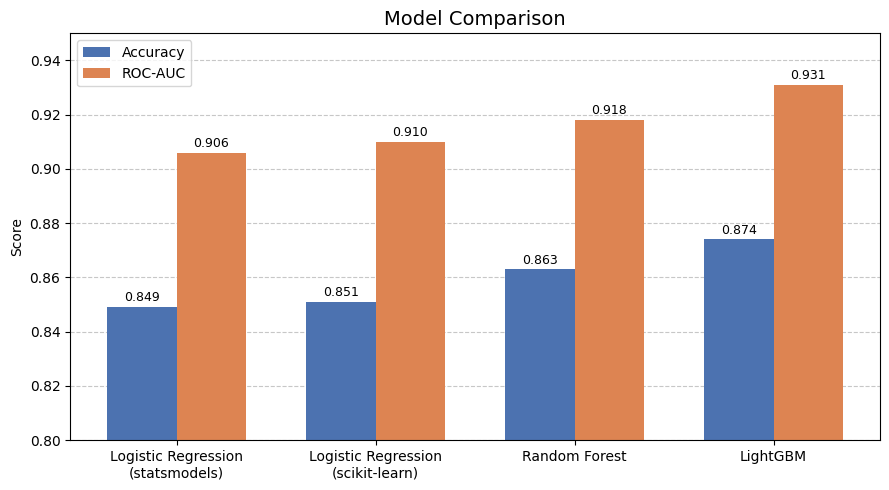

In [10]:
# ============================================================
# 図2：モデル比較
# ============================================================

models = ['Logistic Regression\n(statsmodels)', 'Logistic Regression\n(scikit-learn)', 'Random Forest', 'LightGBM']
accuracy = [0.849, 0.851, 0.863, 0.874]
roc_auc  = [0.906, 0.910, 0.918, 0.931]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy',color='#4C72B0')
bars2 = ax.bar(x + width/2, roc_auc,  width, label='ROC-AUC', color='#DD8452')

# 各バーの上に値を表示
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Model Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0.80, 0.95)  # 差が見えるよう下限を調整
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)  # 横グリッドで読み取りやすく
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': final_model_lgb.feature_importances_})
feature_importance_df.sort_values('importance', ascending=False, ignore_index=True)

,feature,importance
0,relationship,19977.280825
1,capital_gain,15744.225901
2,marital_status,11004.311521
3,education_num,10571.303282
4,age,8034.903012
5,occupation,6676.822998
6,capital_loss,5180.004429
7,hours_per_week,3786.593431
8,workclass,901.219642
9,native_country,580.251830


In [12]:
perm = permutation_importance(
    final_model_lgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=123,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

print(perm_df)

           feature  importance
8     capital_gain    0.060350
0              age    0.051800
3   marital_status    0.030695
2    education_num    0.027763
4       occupation    0.018732
5     relationship    0.014785
9     capital_loss    0.012705
10  hours_per_week    0.012551
1        workclass    0.002917
11  native_country    0.001941
7              sex    0.001493
6             race    0.000694


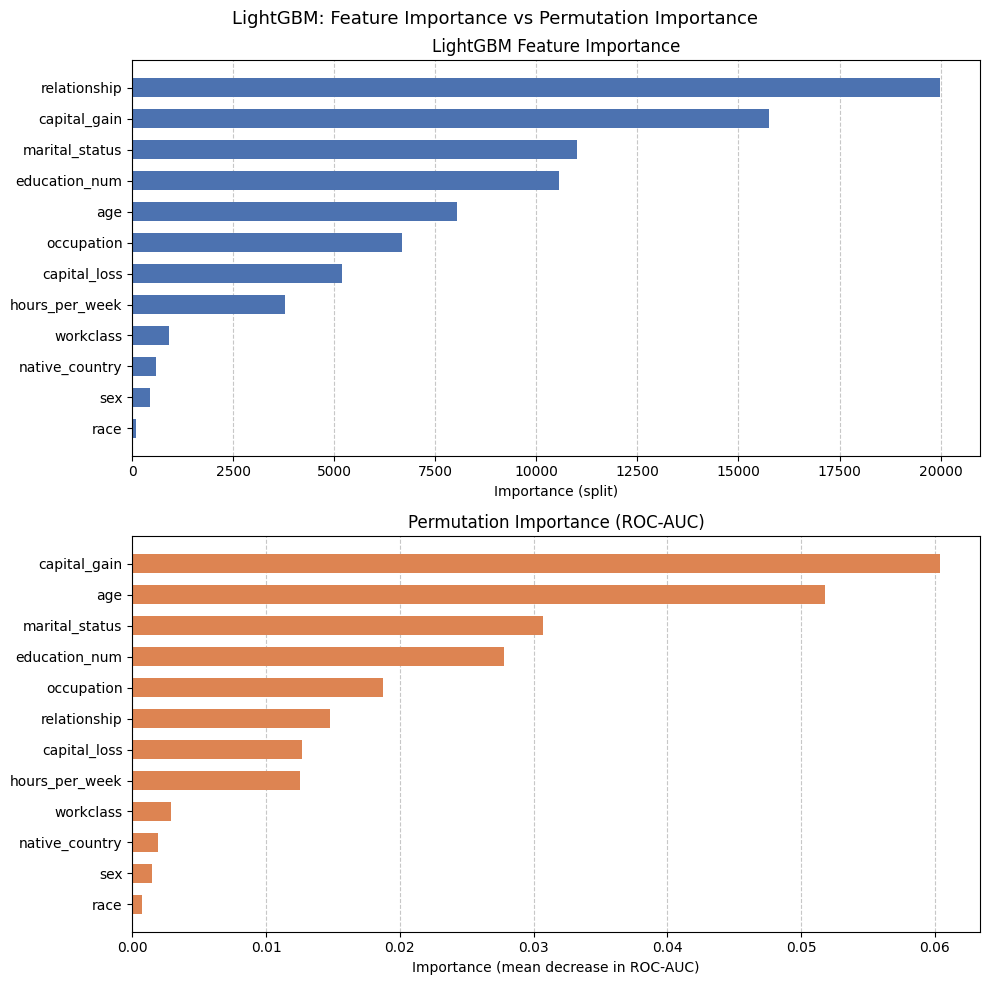

In [13]:
# ============================================================
# 図4：Feature Importance 比較
# ============================================================

# Feature Importance のデータ
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': final_model_lgb.feature_importances_
}).sort_values('importance', ascending=True)  # 横棒グラフは ascending=True で上が高くなる
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Permutation Importance のデータ
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=True)

# 上: Feature Importance
axes[0].barh(feature_importance_df['feature'], feature_importance_df['importance'],
             color='#4C72B0', height=0.6)
axes[0].set_title('LightGBM Feature Importance', fontsize=12)
axes[0].set_xlabel('Importance (split)')
axes[0].xaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# 下: Permutation Importance
axes[1].barh(perm_df['feature'], perm_df['importance'],
             color='#DD8452', height=0.6)
axes[1].set_title('Permutation Importance (ROC-AUC)', fontsize=12)
axes[1].set_xlabel('Importance (mean decrease in ROC-AUC)')
axes[1].xaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.suptitle('LightGBM: Feature Importance vs Permutation Importance', fontsize=13)
plt.tight_layout()
plt.savefig('../images/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/takahashishinji/portfolio/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


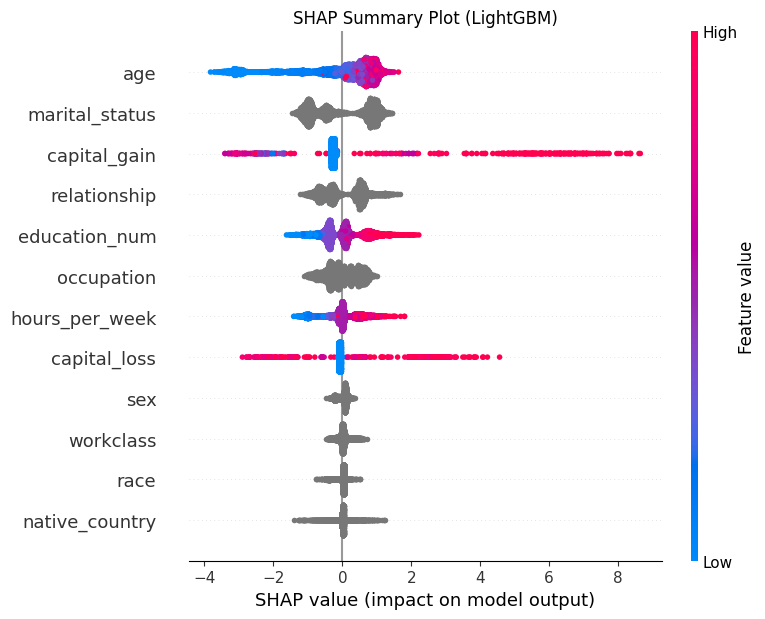

In [14]:
# ============================================================
# 図5：SHAP分析
# ============================================================

explainer = shap.TreeExplainer(final_model_lgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)

plt.title('SHAP Summary Plot (LightGBM)', fontsize=12)
plt.tight_layout()
plt.savefig('../images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### サブグループ分析

In [15]:
df_test = X_test.copy()
df_test['y_true'] = y_test
df_test['y_pred'] = y_pred

# 性別ごとの高所得予測率
df_test.groupby('sex')['y_pred'].mean()

sex
Female    0.082166
Male      0.263784
Name: y_pred, dtype: float64

In [16]:
df_test_married = df_test.loc[df_test['marital_status'] == 'Married-civ-spouse']

# 既婚者に限った性別ごとの高所得予測率
df_test_married.groupby('sex')['y_pred'].mean()

sex
Female    0.423780
Male      0.405639
Name: y_pred, dtype: float64

In [17]:
# 性別ごとのモデル性能
for g in df_test['sex'].unique():
    
    mask = df_test['sex'] == g
    
    auc = roc_auc_score(
        df_test.loc[mask, 'y_true'],
        y_pred_proba[mask]
    )
    
    print(g, auc)

Male 0.9131534271854771
Female 0.9514545795795796


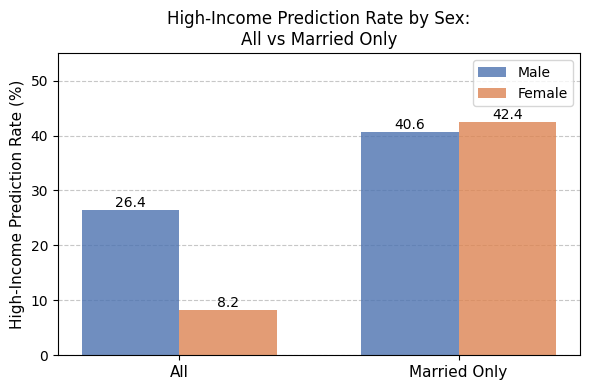

In [18]:
# ============================================================
# 図6：サブグループ分析
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

groups = ['All', 'Married Only']
rates_male   = [26.38, 40.56]
rates_female = [8.22,  42.38]

x = np.arange(len(groups))
width = 0.35

bars1 = ax.bar(x - width/2, rates_male,   width, label='Male',   color='#4C72B0', alpha=0.8)
bars2 = ax.bar(x + width/2, rates_female, width, label='Female', color='#DD8452', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel('High-Income Prediction Rate (%)', fontsize=11)
ax.set_title('High-Income Prediction Rate by Sex:\nAll vs Married Only', fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0, 55)

plt.tight_layout()
plt.savefig('../images/subgroup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ============================================================
# What-If 分析：高収入確率シミュレーション（LightGBM）
# ============================================================
# 特定の属性を持つ架空の人物を作成し、モデルが予測する高収入確率を可視化する。
# capital_gain / capital_loss は逆因果の懸念があるため、全ペルソナで 0 に統一する。
# ============================================================

# ============================================================
# ヘルパー関数
# ============================================================

def make_persona(age, workclass, education_num, marital_status, occupation,
                 relationship, race, sex, capital_gain, capital_loss,
                 hours_per_week, native_country):
    """
    指定した属性値から、モデルに投入できる1行の DataFrame を作成する。
    引数はモデルの学習に使った12列の特徴量に対応している。
    """
    return pd.DataFrame([{
        'age':            age,
        'workclass':      workclass,
        'education_num':  education_num,   # 学歴年数（1〜16の整数）
        'marital_status': marital_status,
        'occupation':     occupation,
        'relationship':   relationship,
        'race':           race,
        'sex':            sex,
        'capital_gain':   capital_gain,
        'capital_loss':   capital_loss,
        'hours_per_week': hours_per_week,
        'native_country': native_country,
    }])


def encode_and_predict(df_input):
    """
    ペルソナ DataFrame をモデルに投入できる形に変換し、高収入確率を返す。

    LightGBM はカテゴリ変数を Categorical 型として受け取る仕様のため、
    X_train のカテゴリ定義（学習時に確定したカテゴリ一覧）を使って
    各カテゴリ列を変換する必要がある。
    X_train と異なるカテゴリ定義を使うと未知カテゴリとして扱われ、
    予測結果がおかしくなる場合があるため注意。

    戻り値：高収入（>$50K）の予測確率（numpy array）
    """
    df = df_input.copy()
    for col in cat_cols:
        # X_train のカテゴリ定義を流用して変換する
        df[col] = pd.Categorical(df[col], categories=X_train[col].cat.categories)
    return final_model_lgb.predict_proba(df)[:, 1]  # [:, 1] で「>50K」クラスの確率を取得

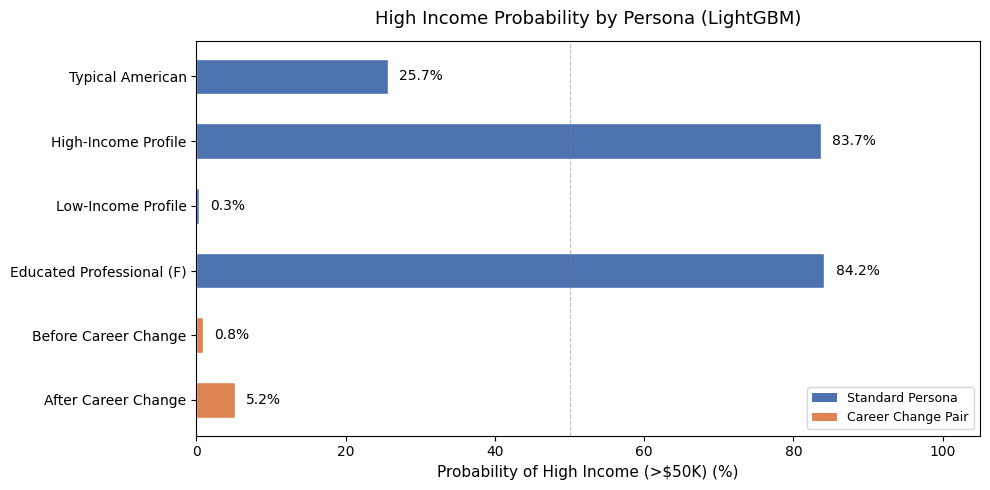

In [20]:
# ============================================================
# 図7：ペルソナ比較
# ============================================================
# 「典型的米国人」を起点に、様々な属性パターンの人物を用意し、
# モデルが予測する高収入確率を横棒グラフで比較する。
# 「キャリアチェンジ前後」はその他の属性を完全に固定し、
# 学歴（9→13）と職業（Adm-clerical→Tech-support）だけを変えた同一人物を想定している。
# ============================================================

# --- ペルソナ定義 ---
personas = {
    # 37歳・高卒・既婚・Craft-repair・週40時間：データの中央値付近を想定
    'Typical American':           make_persona(37, 'Private', 9,  'Married-civ-spouse', 'Craft-repair',    'Husband',      'White', 'Male',   0, 0, 40, 'United-States'),
    # 45歳・学士・既婚・管理職・週50時間：高収入が期待される典型的プロファイル
    'High-Income Profile':        make_persona(45, 'Private', 13, 'Married-civ-spouse', 'Exec-managerial', 'Husband',      'White', 'Male',   0, 0, 50, 'United-States'),
    # 25歳・高卒・未婚・農業・週35時間：低収入が期待される典型的プロファイル
    'Low-Income Profile':         make_persona(25, 'Private', 9,  'Never-married',      'Farming-fishing', 'Not-in-family','White', 'Male',   0, 0, 35, 'United-States'),
    # 35歳・修士・既婚・専門職・週45時間・女性：高学歴キャリア女性を想定
    'Educated Professional (F)':  make_persona(35, 'Private', 14, 'Married-civ-spouse', 'Prof-specialty',  'Wife',         'White', 'Female', 0, 0, 45, 'United-States'),
    # 28歳・高卒・未婚・事務職・週40時間：キャリアチェンジ前
    'Before Career Change':       make_persona(28, 'Private', 9,  'Never-married',      'Adm-clerical',    'Not-in-family','White', 'Male',   0, 0, 40, 'United-States'),
    # 28歳・学士・未婚・技術職・週40時間：学歴と職業のみ変えた同一人物
    'After Career Change':        make_persona(28, 'Private', 13, 'Never-married',      'Tech-support',    'Not-in-family','White', 'Male',   0, 0, 40, 'United-States'),
}

# --- 各ペルソナの高収入確率を計算（%表示） ---
persona_probs = {name: encode_and_predict(df)[0] * 100
                 for name, df in personas.items()}

# --- グラフ描画 ---
fig, ax = plt.subplots(figsize=(10, 5))
# 横棒グラフはデフォルトで下から順に描画されるため、辞書の定義順を逆にする
names = list(persona_probs.keys())[::-1]
probs  = [persona_probs[n] for n in names]
# キャリアチェンジ前後のペルソナはオレンジ、それ以外はブルーで色分け
colors = ['#DD8452' if 'Career' in n else '#4C72B0' for n in names]

bars = ax.barh(names, probs, color=colors, edgecolor='white', height=0.55)
ax.set_xlabel('Probability of High Income (>$50K) (%)', fontsize=11)
ax.set_title('High Income Probability by Persona (LightGBM)', fontsize=13, pad=12)
ax.set_xlim(0, 105)
# 50% の位置に基準線を引く
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# 各バーの右端に確率を数値で表示
for bar, prob in zip(bars, probs):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f'{prob:.1f}%', va='center', fontsize=10)

# 凡例
legend_elements = [
    Patch(facecolor='#4C72B0', label='Standard Persona'),
    Patch(facecolor='#DD8452', label='Career Change Pair'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../images/whatif_personas.png', dpi=150, bbox_inches='tight')
plt.show()

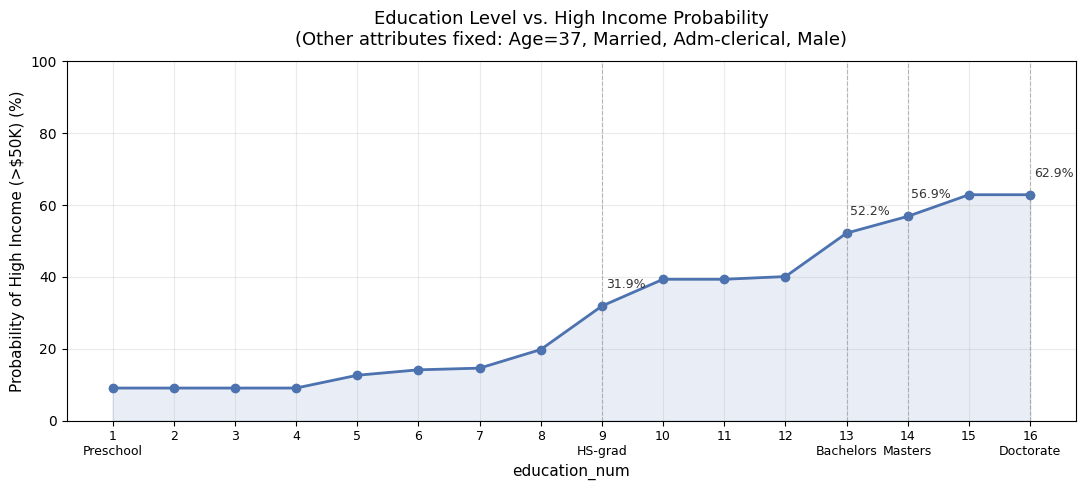

In [21]:
# ============================================================
# 図8：感度分析 — 学歴（education_num）
# ============================================================
# 「典型的米国人」の属性を固定したまま、education_num だけを 1〜16 で変化させる。
# これにより「学歴が変わると高収入確率はどう変化するか」を単変数で確認できる。
# ============================================================

# ベースとなる属性（学歴以外は固定）
BASE_EDU = dict(age=37, workclass='Private', marital_status='Married-civ-spouse',
                occupation='Adm-clerical', relationship='Husband',
                race='White', sex='Male', capital_gain=0, capital_loss=0,
                hours_per_week=40, native_country='United-States')

# education_num を 1〜16 で1ずつ変化させて確率を計算
edu_values = list(range(1, 17))
edu_probs  = [encode_and_predict(make_persona(education_num=e, **BASE_EDU))[0] * 100
              for e in edu_values]

# x 軸：主要な節目のみラベルを付け、それ以外は数値のみ表示
EDU_LABELS = {
    1:  '1\nPreschool',
    9:  '9\nHS-grad',
    13: '13\nBachelors',
    14: '14\nMasters',
    16: '16\nDoctorate',
}
xtick_labels = [EDU_LABELS.get(e, str(e)) for e in edu_values]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(edu_values, edu_probs, marker='o', color='#4C72B0',
        linewidth=2, markersize=6)
# 折れ線の下を薄く塗りつぶして視認性を高める
ax.fill_between(edu_values, edu_probs, alpha=0.12, color='#4C72B0')

# 主要な節目に縦の破線と確率の注釈を追加
for edu in [9, 13, 14, 16]:
    idx = edu - 1
    ax.axvline(edu, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.annotate(f'{edu_probs[idx]:.1f}%',
                xy=(edu, edu_probs[idx]),
                xytext=(edu + 0.06, edu_probs[idx] + 5),
                fontsize=9, color='#333333')

ax.set_xticks(edu_values)
ax.set_xticklabels(xtick_labels, fontsize=9)
ax.set_xlabel('education_num', fontsize=11)
ax.set_ylabel('Probability of High Income (>$50K) (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.set_title(
    'Education Level vs. High Income Probability\n'
    '(Other attributes fixed: Age=37, Married, Adm-clerical, Male)',
    fontsize=13, pad=12
)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('../images/whatif_education.png', dpi=150, bbox_inches='tight')
plt.show()

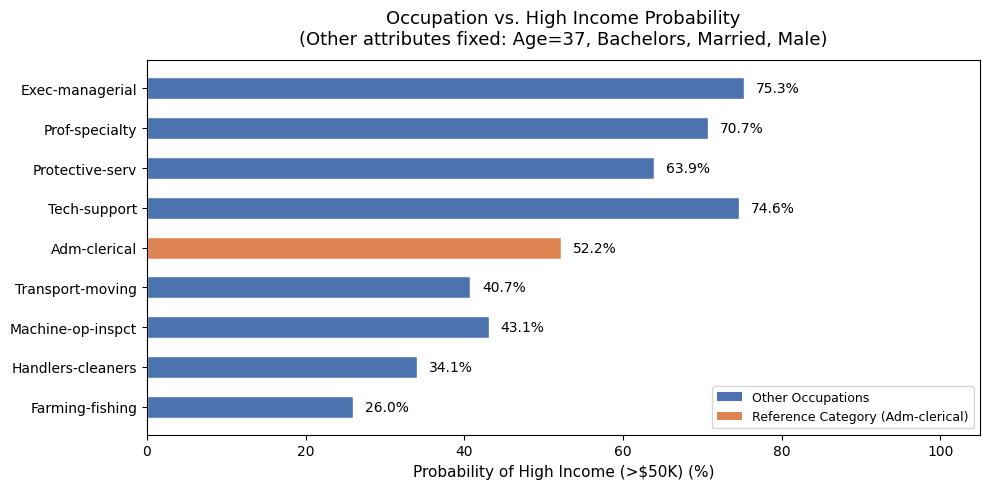

In [22]:
# ============================================================
# 図9：感度分析 — 職業（occupation）
# ============================================================
# 図2との対比として、今度は学歴を大卒（education_num=13）に固定し、
# 職業だけを変化させる。
# 同じ大卒でも職業によって高収入確率がどこまで変わるかを可視化する。
# 職業はオッズ比の結果（図3）で影響が大きかったものを中心に選定した。
# ============================================================

# 比較する職業リスト（上から高収入傾向→低収入傾向の順に並べる）
OCCUPATION_LIST = [
    'Exec-managerial',   # 経営層・管理職：オッズ比で最も高い職種
    'Prof-specialty',    # 専門職（医師・弁護士・会計士・研究者など）
    'Protective-serv',   # 保安職（警察・消防など）
    'Tech-support',      # 技術サポート
    'Adm-clerical',      # 事務職：参照カテゴリ（中間的な職種）
    'Transport-moving',  # 輸送・運転
    'Machine-op-inspct', # 機械オペレーター
    'Handlers-cleaners', # 運搬・清掃
    'Farming-fishing',   # 農業・漁業：オッズ比で最も低い職種
]

# ベースとなる属性（職業以外は固定・学歴は大卒=13に固定）
BASE_OCC = dict(age=37, workclass='Private', education_num=13,
                marital_status='Married-civ-spouse', relationship='Husband',
                race='White', sex='Male', capital_gain=0, capital_loss=0,
                hours_per_week=40, native_country='United-States')

# 各職業の高収入確率を計算
occ_probs = {}
for occ in OCCUPATION_LIST:
    p = make_persona(occupation=occ, **BASE_OCC)
    occ_probs[occ] = encode_and_predict(p)[0] * 100

# --- グラフ描画 ---
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(occ_probs.keys())[::-1]
probs  = [occ_probs[l] for l in labels]
# 事務職（参照カテゴリ）のみオレンジで強調、他はブルー
colors = ['#DD8452' if l == 'Adm-clerical' else '#4C72B0' for l in labels]

bars = ax.barh(labels, probs, color=colors, edgecolor='white', height=0.55)
ax.set_xlabel('Probability of High Income (>$50K) (%)', fontsize=11)
ax.set_title(
    'Occupation vs. High Income Probability\n'
    '(Other attributes fixed: Age=37, Bachelors, Married, Male)',
    fontsize=13, pad=12
)
ax.set_xlim(0, 105)

# 各バーの右端に確率を数値で表示
for bar, prob in zip(bars, probs):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f'{prob:.1f}%', va='center', fontsize=10)

# 凡例（参照カテゴリの説明）
legend_elements = [
    Patch(facecolor='#4C72B0', label='Other Occupations'),
    Patch(facecolor='#DD8452', label='Reference Category (Adm-clerical)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../images/whatif_occupation.png', dpi=150, bbox_inches='tight')
plt.show()